<a href="https://colab.research.google.com/github/dawid-wilgucki/masters-thesis-lung-classification/blob/main/notebooks/Magisterka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run once to install all required packages
!pip install -q torch torchvision matplotlib scikit-learn tqdm pillow medmnist hyperopt pandas seaborn grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.8 MB/s eta 0:00:00


# Comparison of Hyperparameter Optimization Methods in Detecting Lung Diseases from Medical Images

**Master's Thesis — Experiment Notebook**

## Objective
This notebook trains three convolutional neural network architectures (ResNet-18, ResNet-50, MobileNet-V2) on the PneumoniaMNIST dataset and compares three hyperparameter optimization strategies:

| Strategy | Description |
|---|---|
| **Baseline** | Fixed hyperparameters chosen by hand |
| **Grid Search** | Exhaustive search over a discrete parameter grid |
| **Hyperopt (TPE)** | Bayesian optimization using Tree of Parzen Estimators |

## Architectures

| Architecture | Params | Notes |
|---|---|---|
| ResNet-18 | ~11M | Lightweight baseline |
| ResNet-50 | ~25M | Deeper residual network |
| MobileNet-V2 | ~3.4M | Efficient lightweight model |

## Dataset
[PneumoniaMNIST](https://medmnist.com/) — part of the MedMNIST v2 benchmark. Binary classification: NORMAL vs PNEUMONIA.
Source images: Chest X-Ray Images (Guangzhou Women and Children's Medical Center).

- **Train**: 4,708 images (~73% PNEUMONIA, ~27% NORMAL)
- **Val**: 524 images (official MedMNIST split, used for hyperparameter selection)
- **Test**: 624 images (held out for final evaluation)
- **Resolution**: 224×224 px (requested via `size=224` in MedMNIST API)
- **Loss**: Weighted CrossEntropyLoss — weights inversely proportional to class frequency to handle ~73%/27% class imbalance.

## Evaluation Metrics
Because the dataset is class-imbalanced (PNEUMONIA ~73% of training data), accuracy alone is insufficient. We report:
- **Accuracy** — overall correctness
- **Weighted F1-score** — harmonic mean of precision/recall, weighted by class size
- **ROC-AUC** — discriminative ability independent of classification threshold

## 1. Imports and Reproducibility Seeds

Setting fixed seeds ensures that every run of this notebook produces identical results, which is a requirement for reproducible research.

In [ ]:
import os
import copy
import time
import json
import pickle
import random
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, accuracy_score
)

import medmnist
from medmnist import PneumoniaMNIST
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# num_workers=0 on Windows avoids multiprocessing spawn errors with DataLoader
# Oversubscribing workers on a 2-vCPU Colab VM slows the DataLoader and can freeze it
NUM_WORKERS = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)

print(f"Device : {device}")
print(f"Workers: {NUM_WORKERS}")
print(f"PyTorch: {torch.__version__}")


def compute_class_weights(dataset):
    """
    Compute inverse-frequency class weights.
    Supports both ImageFolder (.targets) and MedMNIST (.labels) APIs.
    """
    if hasattr(dataset, 'labels'):
        labels = torch.tensor(dataset.labels.flatten(), dtype=torch.long)
    else:
        labels = torch.tensor([dataset.targets[i] for i in range(len(dataset))], dtype=torch.long)
    counts = torch.bincount(labels)
    weights = 1.0 / counts.float()
    weights = weights / weights.sum()
    return weights.to(device)

Device : cuda
Workers: 4
PyTorch: 2.11.0+cu128


## 2. Data Loading and Preprocessing

### Why these transforms?
- **`Grayscale(num_output_channels=3)`** — X-ray images are single-channel; ResNet/MobileNet were pretrained on 3-channel ImageNet images, so we replicate the grayscale channel three times to match the expected input shape.
- **`Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`** — ImageNet mean/std used during CNN pretraining. Applying the same normalization ensures that the pretrained feature representations remain valid.
- **Augmentation (train only)** — Random flip and rotation improve generalization by making the model invariant to small spatial variations. Applied only to training data to avoid contaminating validation statistics.

Augmentation is applied exclusively to training data after the train/val split to prevent leakage into validation statistics.

### Dataset split
PneumoniaMNIST provides an official val split (524 images), which is used directly for hyperparameter selection during training. This avoids the methodological compromise of using the test set as a proxy validation set.

In [ ]:
# ── ImageNet normalization constants ──────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(augment: bool = False) -> transforms.Compose:
    """Return a transform pipeline for train (augment=True) or val/test."""
    base = [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # 1-ch → 3-ch for CNN
    ]
    if augment:
        base += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    base += [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    return transforms.Compose(base)


def get_dataloaders(batch_size: int = 32):
    """
    Build DataLoaders using PneumoniaMNIST from the MedMNIST benchmark.

    PneumoniaMNIST provides a proper val split (524 images) — unlike the
    original Kaggle dataset which had only 16 val images and required using
    the test split for validation. Split sizes: train=4708, val=524, test=624.
    """
    # Augmentation is applied ONLY to the training split and ONLY
    # after the train/val split is defined — never to validation data.
    # This prevents data leakage that would inflate validation metrics.
    image_datasets = {
        'train': PneumoniaMNIST(split='train', transform=get_transforms(augment=True),
                                download=True, size=224),
        'val':   PneumoniaMNIST(split='val',   transform=get_transforms(augment=False),
                                download=True, size=224),
    }
    dataloaders = {
        k: torch.utils.data.DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(k == 'train'),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == 'cuda'),
        )
        for k, ds in image_datasets.items()
    }
    sizes       = {k: len(ds) for k, ds in image_datasets.items()}
    class_names = ['NORMAL', 'PNEUMONIA']
    return dataloaders, sizes, class_names


# Sanity check
_dls, _sizes, CLASS_NAMES = get_dataloaders()
print("Classes :", CLASS_NAMES)
print("Sizes   :", _sizes)

100%|██████████| 214M/214M [00:37<00:00, 5.68MB/s]


Classes : ['NORMAL', 'PNEUMONIA']
Sizes   : {'train': 4708, 'val': 524}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# ── Sprawdzenie rozmiaru obrazów ──────────────────────────────────────────────
# Surowy rozmiar z MedMNIST (bez transformacji) — potwierdza, że obrazy są
# natywnie pobrane w 224x224 (parametr size=224), a nie skalowane z 28x28.
raw_ds = PneumoniaMNIST(split='train', download=True, size=224)
raw_img, _ = raw_ds[0]
print("Surowy rozmiar obrazu z MedMNIST (W, H):", raw_img.size)

# Rozmiar tensora faktycznie wchodzącego do sieci, po Resize/Grayscale/ToTensor
batch_imgs, batch_labels = next(iter(_dls["train"]))
print("Kształt batcha (N, C, H, W):          ", tuple(batch_imgs.shape))
print("Kształt pojedynczego obrazu (C, H, W):", tuple(batch_imgs[0].shape))
print("Kształt batcha etykiet (przed reshape):", tuple(batch_labels.shape))

Surowy rozmiar obrazu z MedMNIST (W, H): (224, 224)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Kształt batcha (N, C, H, W):           (32, 3, 224, 224)
Kształt pojedynczego obrazu (C, H, W): (3, 224, 224)
Kształt batcha etykiet (przed reshape): (32, 1)


## 3. Model Definition

### Why pretrained CNNs with transfer learning?
All three architectures are initialised with ImageNet pretrained weights. Pretrained networks provide strong low-level feature detectors (edges, textures) that transfer well to medical images. Fine-tuning all layers (rather than only the classification head) typically yields better performance when training data is sufficient, as it is here (~5K images).

The final classification layer is replaced with a 2-output linear head matching the binary task:

| Architecture | Original head | Replacement |
|---|---|---|
| ResNet-18 / ResNet-50 | `model.fc` (512 / 2048 → 1000) | `nn.Linear(in, 2)` |
| MobileNet-V2 | `model.classifier[1]` (1280 → 1000) | `nn.Linear(1280, 2)` |

In [ ]:
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    MobileNet_V2_Weights,
)

ARCHITECTURES = {
    "resnet18":  lambda: models.resnet18(weights=ResNet18_Weights.DEFAULT),
    "resnet50":  lambda: models.resnet50(weights=ResNet50_Weights.DEFAULT),
    "mobilenet": lambda: models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT),
}


def build_model(arch_name: str = "resnet18", num_classes: int = 2) -> nn.Module:
    """
    Build pretrained CNN with classifier head replaced for binary classification.

    Architectures:
      resnet18  — lightweight baseline (~11M params)
      resnet50  — deeper residual network (~25M params)
      mobilenet — efficient lightweight model (~3.4M params)
    """
    model = ARCHITECTURES[arch_name]()

    if arch_name in ("resnet18", "resnet50"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif arch_name == "mobilenet":
        in_feat = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_feat, num_classes)

    return model.to(device)

## 4. Training and Evaluation Functions

### Training loop design decisions
- **Early stopping** (`patience` parameter) halts training when validation accuracy stops improving. This prevents overfitting and reduces unnecessary compute during hyperparameter search.
- **Best-weights checkpointing** restores the model weights from the epoch with the highest validation accuracy — not the final epoch.
- **History dict** records per-epoch loss and accuracy for later visualization and comparison.

### Evaluation metrics
- Accuracy, Weighted F1, ROC-AUC are reported for each configuration.
- ROC-AUC is particularly important for medical screening tasks where the cost of false negatives (missed pneumonia) is much higher than false positives.
- **Class-weighted loss** — Class-weighted loss penalises misclassification of the minority class (NORMAL, ~26%) more heavily to counteract dataset imbalance.

In [ ]:
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    dataloaders: dict,
    dataset_sizes: dict,
    num_epochs: int = 10,
    patience: int = 5,
    verbose: bool = True,
) -> tuple:
    """
    Train model with early stopping and best-weight checkpointing.
    Returns (best_model, history_dict).
    """
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    no_improve   = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs}  " + "-" * 20)

        for phase in ("train", "val"):
            model.train() if phase == "train" else model.eval()
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.reshape(-1).to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects / dataset_sizes[phase]
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if verbose:
                print(f"  {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

            if phase == "val":
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_wts     = copy.deepcopy(model.state_dict())
                    no_improve   = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping triggered at epoch {epoch+1}")
            break

    elapsed = time.time() - since
    model.load_state_dict(best_wts)
    history["best_val_acc"] = best_val_acc
    history["elapsed_s"]    = elapsed

    if verbose:
        print(f"\nDone in {elapsed//60:.0f}m {elapsed%60:.0f}s — best val acc: {best_val_acc:.4f}")
    return model, history


def evaluate_model(model: nn.Module, dataloader, class_names: list) -> dict:
    """Compute accuracy, weighted F1, and ROC-AUC on a dataloader."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.reshape(-1).numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # P(PNEUMONIA)

    return {
        "accuracy" : accuracy_score(all_labels, all_preds),
        "f1"       : f1_score(all_labels, all_preds, average="weighted"),
        "roc_auc"  : roc_auc_score(all_labels, all_probs),
        "report"   : classification_report(all_labels, all_preds, target_names=class_names),
        "cm"       : confusion_matrix(all_labels, all_preds),
    }

## 5. Visualization Helpers

In [ ]:
def plot_training_history(history: dict, title: str = "Training History") -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(history[f"train_{metric}"], label="Train", marker="o")
        ax.plot(history[f"val_{metric}"],   label="Val",   marker="s")
        ax.set_title(f"{title} — {metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, class_names: list, title: str = "Confusion Matrix") -> None:
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def show_sample_predictions(model: nn.Module, dataloader, class_names: list, n: int = 8) -> None:
    """Display n sample images with true vs predicted labels."""
    model.eval()
    inputs_batch, labels_batch = next(iter(dataloader))
    inputs_batch = inputs_batch[:n]
    labels_batch = labels_batch[:n]

    with torch.no_grad():
        preds = model(inputs_batch.to(device)).argmax(dim=1).cpu()

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    for i in range(n):
        img = inputs_batch[i] * std + mean
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        color = "green" if preds[i] == labels_batch[i] else "red"
        axes[i].imshow(img[:, :, 0], cmap="gray")
        axes[i].set_title(
            f"True: {class_names[labels_batch[i]]}\nPred: {class_names[preds[i]]}",
            color=color, fontsize=8
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Experiment Tracking

All results are accumulated in a list and later converted to a pandas DataFrame. This enables easy comparison across all optimization strategies and export to CSV for thesis reporting.

In [ ]:
# Central log — every experiment appends one row here
results_log: list[dict] = []

# Results and model weights are checkpointed after every trial so that a Colab
# disconnect mid-run does not discard completed experiments. Colab's local disk
# dies with the session, so checkpoints go to Google Drive when it is available.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_ROOT = "/content/drive/MyDrive/magisterka_checkpoints"
except ImportError:
    CKPT_ROOT = "."          # running outside Colab — keep them alongside the notebook

RESULTS_CKPT = f"{CKPT_ROOT}/results_checkpoint.json"
CKPT_DIR     = f"{CKPT_ROOT}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoints: {CKPT_ROOT}")


def log_result(
    method: str,
    config: dict,
    metrics: dict,
    elapsed_s: float,
) -> None:
    results_log.append({
        "method"      : method,
        **config,
        "val_accuracy": round(metrics["accuracy"], 4),
        "val_f1"      : round(metrics["f1"],       4),
        "val_roc_auc" : round(metrics["roc_auc"],  4),
        "elapsed_s"   : round(elapsed_s, 1),
    })
    with open(RESULTS_CKPT, "w") as f:
        json.dump(results_log, f, indent=2)


def restore_results() -> None:
    """Reload results logged by a previous, interrupted session."""
    if not os.path.exists(RESULTS_CKPT):
        print("No checkpoint found — starting from scratch.")
        return
    with open(RESULTS_CKPT) as f:
        saved = json.load(f)
    results_log.clear()
    results_log.extend(saved)
    print(f"Restored {len(results_log)} results from {RESULTS_CKPT}")


def is_done(method: str, arch: str, config: dict | None = None) -> bool:
    """True if this exact trial already completed in an earlier session."""
    for r in results_log:
        if r.get("method") != method or r.get("arch") != arch:
            continue
        if config is None or all(r.get(k) == v for k, v in config.items()):
            return True
    return False


def best_logged_acc(method: str) -> float:
    """Highest val accuracy recorded so far for a method (0.0 if none)."""
    scores = [r["val_accuracy"] for r in results_log if r.get("method") == method]
    return max(scores) if scores else 0.0


def save_best(tag: str, model: nn.Module, config: dict) -> None:
    torch.save(
        {"state_dict": model.state_dict(), "config": config},
        f"{CKPT_DIR}/best_{tag}.pt",
    )


def load_best(tag: str) -> tuple:
    """Return (model, config) restored from disk, or (None, None) if absent."""
    path = f"{CKPT_DIR}/best_{tag}.pt"
    if not os.path.exists(path):
        return None, None
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    model = build_model(arch_name=ckpt["config"]["arch"], num_classes=len(CLASS_NAMES))
    model.load_state_dict(ckpt["state_dict"])
    return model.to(device), ckpt["config"]


restore_results()

## 7. Experiment 1 — Baseline (Fixed Hyperparameters)

The baseline uses manually chosen hyperparameters without any systematic search. This serves as the reference point for evaluating the benefit of automated optimization.

**Configuration rationale:**
- `lr=1e-4` — small learning rate for fine-tuning a pretrained network
- `batch_size=32` — balance between GPU memory and gradient stability
- `StepLR` — reduces LR by factor 0.1 every 3 epochs to allow fine convergence


  Architecture: RESNET18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]


Epoch 1/10  --------------------
  train  loss=0.1352  acc=0.9499
  val    loss=0.0728  acc=0.9847
Epoch 2/10  --------------------
  train  loss=0.0803  acc=0.9692
  val    loss=0.0599  acc=0.9695
Epoch 3/10  --------------------
  train  loss=0.0561  acc=0.9792
  val    loss=0.0457  acc=0.9809
Epoch 4/10  --------------------
  train  loss=0.0346  acc=0.9883
  val    loss=0.0377  acc=0.9905
Epoch 5/10  --------------------
  train  loss=0.0325  acc=0.9881
  val    loss=0.0378  acc=0.9924
Epoch 6/10  --------------------
  train  loss=0.0268  acc=0.9894
  val    loss=0.0348  acc=0.9962
Epoch 7/10  --------------------
  train  loss=0.0333  acc=0.9898
  val    loss=0.0347  acc=0.9943
Epoch 8/10  --------------------
  train  loss=0.0271  acc=0.9896
  val    loss=0.0352  acc=0.9962
Epoch 9/10  --------------------
  train  loss=0.0258  acc=0.9915
  val    loss=0.0359  acc=0.9962
Epoch 10/10  --------------------
  train  loss=0.0311  acc=0.9909
  val    loss=0.0352  acc=0.9962

Done in 

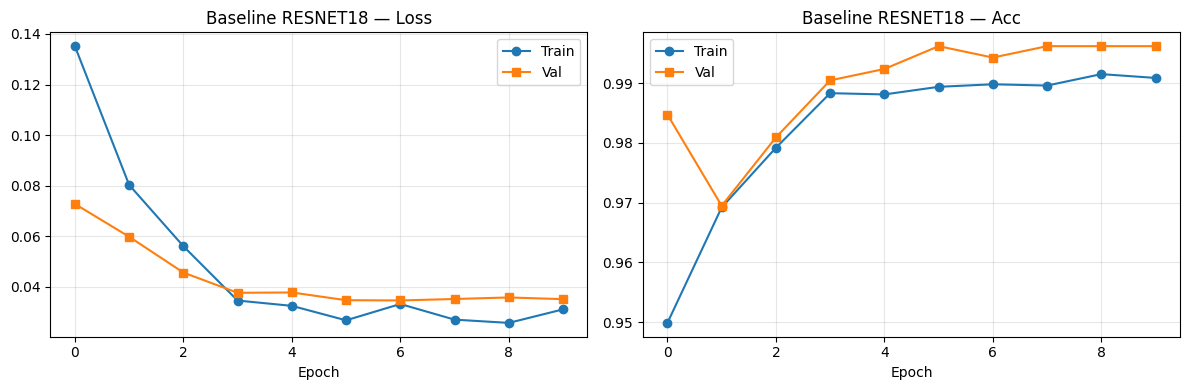

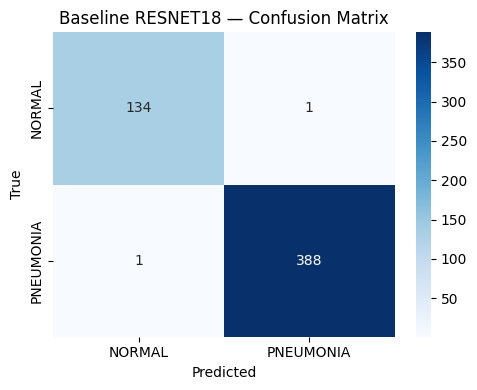

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


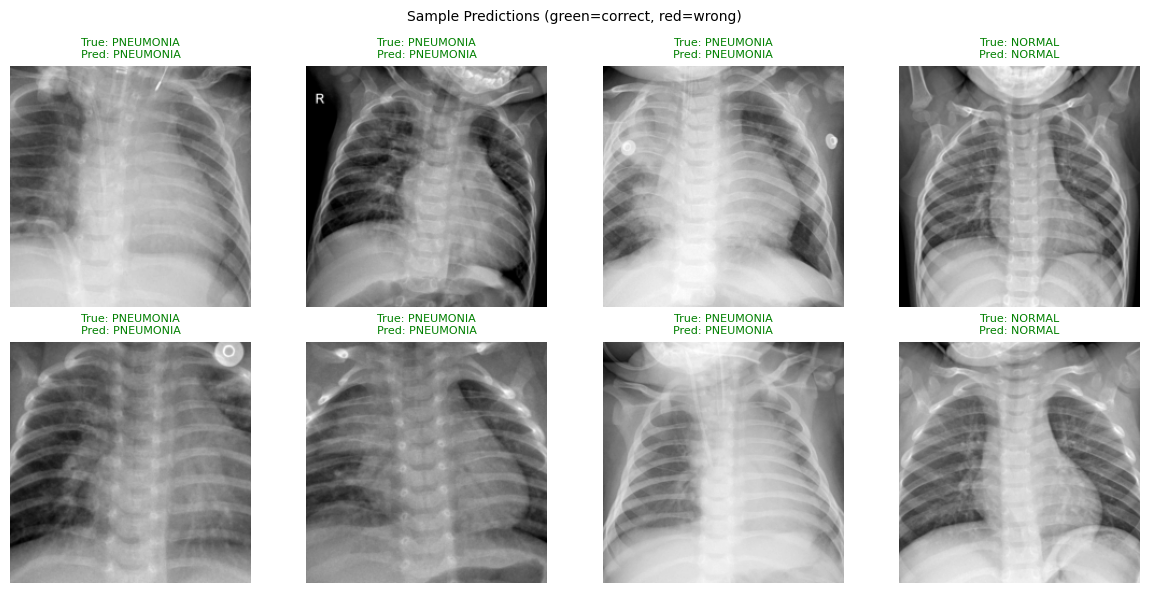


  Architecture: RESNET50


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


Epoch 1/10  --------------------
  train  loss=0.1736  acc=0.9403
  val    loss=0.0794  acc=0.9637
Epoch 2/10  --------------------
  train  loss=0.0902  acc=0.9639
  val    loss=0.0609  acc=0.9771
Epoch 3/10  --------------------
  train  loss=0.0661  acc=0.9775
  val    loss=0.0551  acc=0.9771
Epoch 4/10  --------------------
  train  loss=0.0458  acc=0.9792
  val    loss=0.0446  acc=0.9847
Epoch 5/10  --------------------
  train  loss=0.0408  acc=0.9853
  val    loss=0.0400  acc=0.9866
Epoch 6/10  --------------------
  train  loss=0.0359  acc=0.9877
  val    loss=0.0418  acc=0.9847
Epoch 7/10  --------------------
  train  loss=0.0326  acc=0.9883
  val    loss=0.0380  acc=0.9905
Epoch 8/10  --------------------
  train  loss=0.0318  acc=0.9892
  val    loss=0.0374  acc=0.9885
Epoch 9/10  --------------------
  train  loss=0.0306  acc=0.9896
  val    loss=0.0381  acc=0.9905
Epoch 10/10  --------------------
  train  loss=0.0293  acc=0.9898
  val    loss=0.0384  acc=0.9866

Done in 

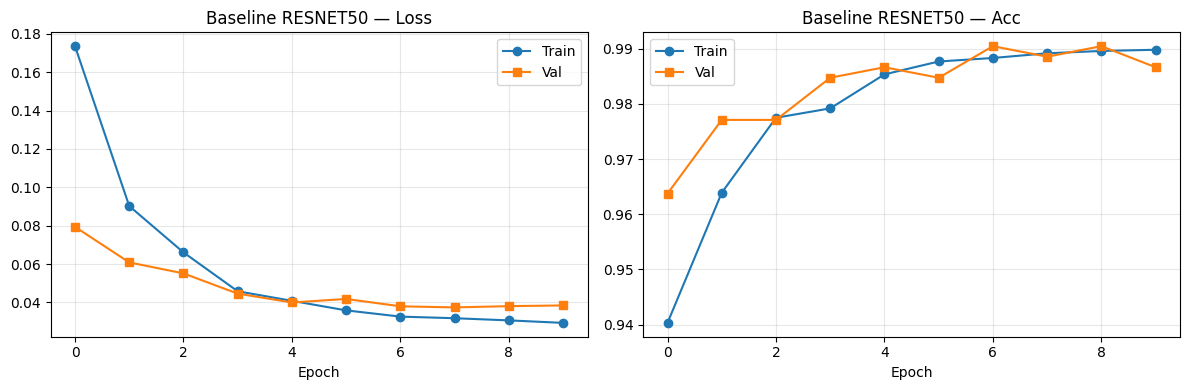

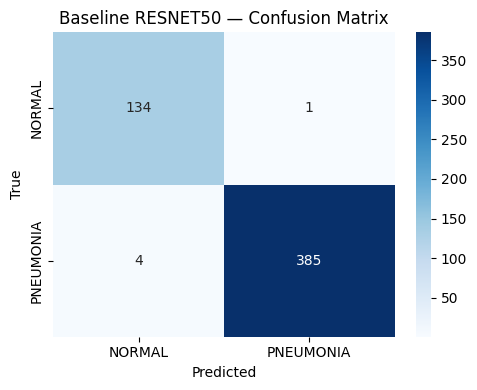

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


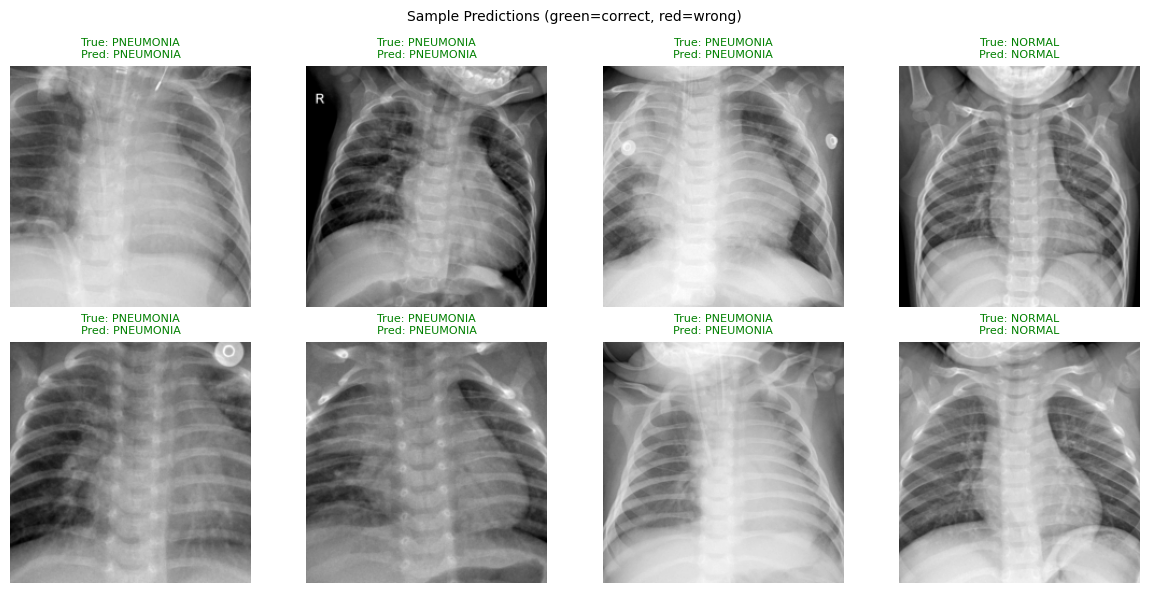


  Architecture: MOBILENET


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 155MB/s]

Epoch 1/10  --------------------


  train  loss=0.2467  acc=0.9131
  val    loss=0.1042  acc=0.9542
Epoch 2/10  --------------------
  train  loss=0.1093  acc=0.9594
  val    loss=0.0672  acc=0.9733
Epoch 3/10  --------------------
  train  loss=0.0805  acc=0.9692
  val    loss=0.0701  acc=0.9790
Epoch 4/10  --------------------
  train  loss=0.0674  acc=0.9790
  val    loss=0.0590  acc=0.9752
Epoch 5/10  --------------------
  train  loss=0.0592  acc=0.9785
  val    loss=0.0528  acc=0.9790
Epoch 6/10  --------------------
  train  loss=0.0616  acc=0.9785
  val    loss=0.0545  acc=0.9809
Epoch 7/10  --------------------
  train  loss=0.0614  acc=0.9800
  val    loss=0.0561  acc=0.9790
Epoch 8/10  --------------------
  train  loss=0.0604  acc=0.9805
  val    loss=0.0554  acc=0.9771
Epoch 9/10  --------------------
  train  loss=0.0481  acc=0.9856
  val    loss=0.0572  acc=0.9847
Epoch 10/10  --------------------
  train  loss=0.0564  acc=0.9807
  val    loss=0.0611  acc=0.9847

Done in 3m 34s — best val acc: 0.9847

  

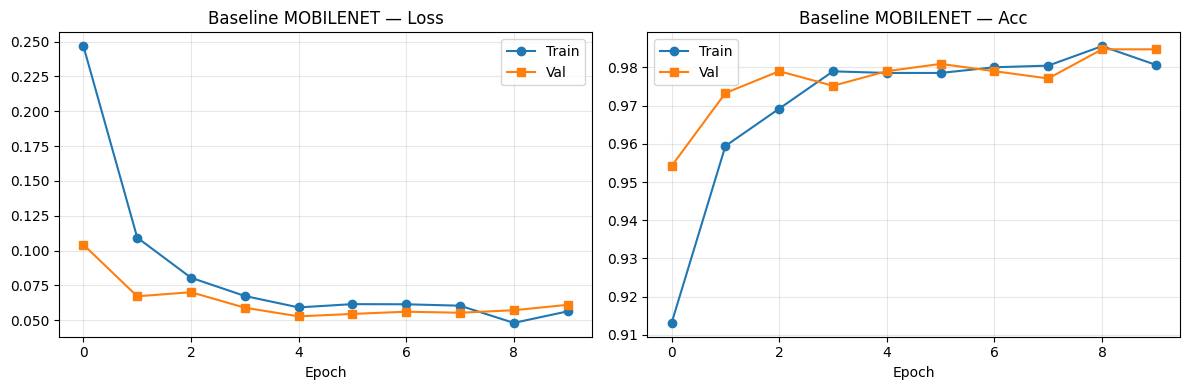

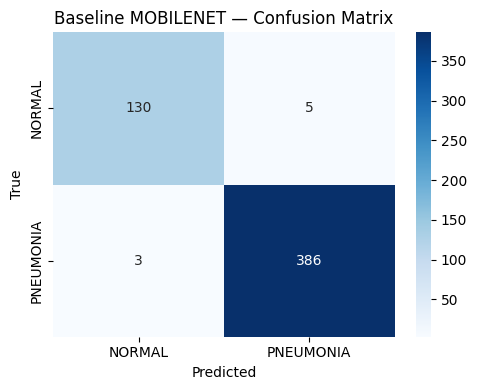

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


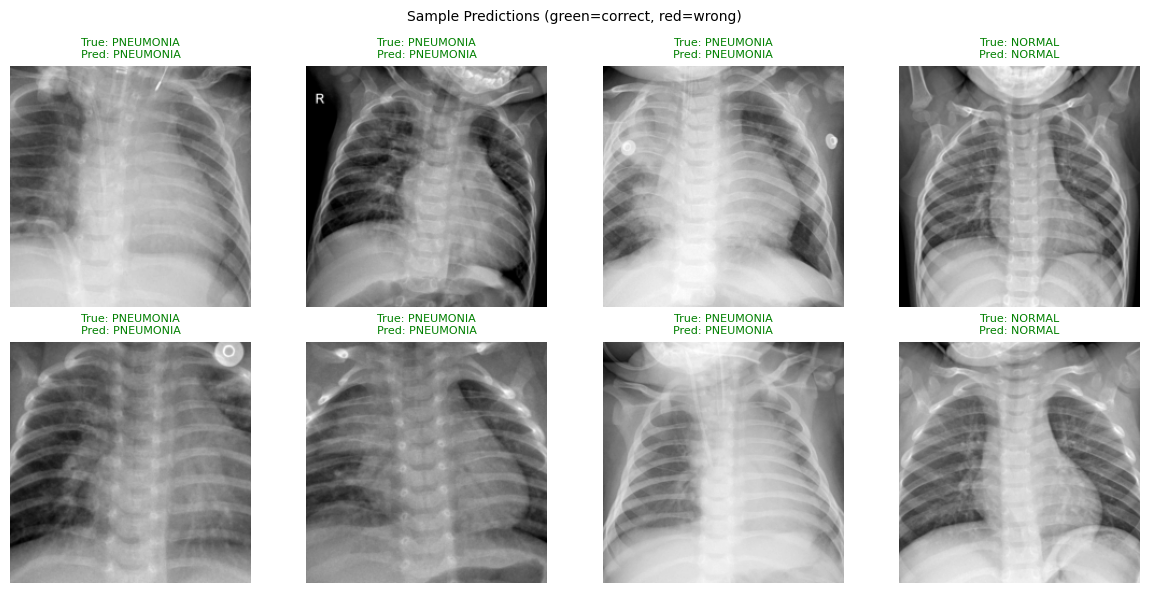

In [ ]:
BASELINE_CONFIG = {
    "lr"          : 1e-4,
    "batch_size"  : 32,
    "weight_decay": 0.0,
    "optimizer"   : "adam",
    "num_epochs"  : 10,
}

bl_model = bl_loaders = None
bl_trained_arch = None

for ARCH in ["resnet18", "resnet50", "mobilenet"]:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    if is_done("Baseline", ARCH):
        print("  Skipped — already completed in an earlier session.")
        continue

    torch.manual_seed(SEED)
    bl_loaders, bl_sizes, CLASS_NAMES = get_dataloaders(BASELINE_CONFIG["batch_size"])

    bl_model      = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
    class_weights = compute_class_weights(bl_loaders['train'].dataset)
    bl_crit       = nn.CrossEntropyLoss(weight=class_weights)
    bl_opt        = torch.optim.Adam(bl_model.parameters(), lr=BASELINE_CONFIG["lr"])
    bl_sched      = lr_scheduler.StepLR(bl_opt, step_size=3, gamma=0.1)

    bl_model, bl_history = train_model(
        bl_model, bl_crit, bl_opt, bl_sched,
        bl_loaders, bl_sizes,
        num_epochs=BASELINE_CONFIG["num_epochs"],
        patience=5,
    )

    bl_metrics = evaluate_model(bl_model, bl_loaders["val"], CLASS_NAMES)
    log_result("Baseline", {**BASELINE_CONFIG, "arch": ARCH}, bl_metrics, bl_history["elapsed_s"])
    save_best(f"baseline_{ARCH}", bl_model, {**BASELINE_CONFIG, "arch": ARCH})
    bl_trained_arch = ARCH

    print("\n" + bl_metrics["report"])
    plot_training_history(bl_history, f"Baseline {ARCH.upper()}")
    plot_confusion_matrix(bl_metrics["cm"], CLASS_NAMES, f"Baseline {ARCH.upper()} — Confusion Matrix")
    show_sample_predictions(bl_model, bl_loaders["val"], CLASS_NAMES)

# ARCH now holds the last architecture of the loop — the representative Baseline
# model used by the ROC and Grad-CAM sections. Restore it if it was skipped here.
if bl_trained_arch != ARCH:
    bl_model, _      = load_best(f"baseline_{ARCH}")
    bl_loaders, _, _ = get_dataloaders(BASELINE_CONFIG["batch_size"])
    print(f"\nBaseline model ({ARCH.upper()}) restored from checkpoint.")

## 8. Experiment 2 — Grid Search

### Method
Grid Search exhaustively evaluates every combination of hyperparameter values from a predefined discrete grid. The number of trials equals the Cartesian product of all grid dimensions.

**Search space** (3 × 2 × 2 = **12 trials**):

| Hyperparameter | Values |
|---|---|
| Learning rate | 1e-3, 1e-4, 1e-5 |
| Batch size | 16, 32 |
| Weight decay | 0.0, 1e-4 |

### Limitation
Grid Search scales exponentially with the number of hyperparameters. It treats each parameter independently and cannot model interactions between them.

In [1]:
GRID = {
    "lr"          : [1e-3, 1e-4, 1e-5],
    "batch_size"  : [16, 32],
    "weight_decay": [0.0, 1e-4],
}

grid_keys   = list(GRID.keys())
grid_values = list(GRID.values())
grid_combos = list(product(*grid_values))
print(f"Grid Search: {len(grid_combos)} trials per architecture")

# Seed from the checkpoint so a resumed run does not overwrite a better model
# found in an earlier session with a weaker one from this session.
best_grid_acc     = best_logged_acc("GridSearch")
best_grid_config  = None
best_grid_model   = None
best_grid_arch    = None
best_grid_loaders = None

for ARCH in ["resnet18", "resnet50", "mobilenet"]:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    for trial_idx, combo in enumerate(grid_combos, 1):
        config = dict(zip(grid_keys, combo))
        print(f"\n[Grid {trial_idx}/{len(grid_combos)}] {config}")

        if is_done("GridSearch", ARCH, config):
            print("  Skipped — already completed in an earlier session.")
            continue

        torch.manual_seed(SEED)  # same seed for every trial → fair comparison
        gs_loaders, gs_sizes, _ = get_dataloaders(config["batch_size"])

        m             = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
        class_weights = compute_class_weights(gs_loaders['train'].dataset)
        crit          = nn.CrossEntropyLoss(weight=class_weights)
        opt           = torch.optim.Adam(m.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        sched         = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

        m, hist = train_model(
            m, crit, opt, sched,
            gs_loaders, gs_sizes,
            num_epochs=8, patience=3, verbose=False
        )
        metrics = evaluate_model(m, gs_loaders["val"], CLASS_NAMES)
        log_result("GridSearch", {**config, "num_epochs": 8, "optimizer": "adam", "arch": ARCH},
                   metrics, hist["elapsed_s"])

        print(f"  acc={metrics['accuracy']:.4f}  f1={metrics['f1']:.4f}  auc={metrics['roc_auc']:.4f}")

        if metrics["accuracy"] > best_grid_acc:
            best_grid_acc     = metrics["accuracy"]
            best_grid_config  = {**config, "arch": ARCH}
            best_grid_model   = copy.deepcopy(m)
            best_grid_arch    = ARCH
            best_grid_loaders = gs_loaders
            save_best("gridsearch", m, best_grid_config)

# Every trial may have been restored from an earlier session, leaving no model
# in memory — reload the best one from disk for the downstream sections.
if best_grid_model is None:
    best_grid_model, best_grid_config = load_best("gridsearch")
    if best_grid_model is None:
        raise RuntimeError("No Grid Search checkpoint found — run the search at least once.")
    best_grid_arch          = best_grid_config["arch"]
    best_grid_loaders, _, _ = get_dataloaders(best_grid_config["batch_size"])
    print("\nBest Grid Search model restored from checkpoint.")

print(f"\nBest Grid Search config : {best_grid_config}")
print(f"Best Grid Search val acc: {best_grid_acc:.4f}")

NameError: name 'product' is not defined

In [ ]:
# Detailed report for the best Grid Search configuration
gs_best_metrics = evaluate_model(best_grid_model, best_grid_loaders["val"], CLASS_NAMES)
print(gs_best_metrics["report"])
plot_confusion_matrix(gs_best_metrics["cm"], CLASS_NAMES, f"Best Grid Search ({best_grid_arch}) — Confusion Matrix")

## 9. Experiment 3 — Hyperopt (Bayesian Optimization with TPE)

### Method
Hyperopt uses the **Tree of Parzen Estimators (TPE)** algorithm — a Bayesian optimization method. Unlike Grid Search, TPE:
- Models the probability distribution of good vs bad configurations based on past trials
- Focuses sampling in promising regions of the search space
- Handles continuous parameters (e.g., `lr` on a log scale) natively

**Search space** (**20 trials**, larger continuous space):

| Hyperparameter | Distribution |
|---|---|
| Learning rate | Log-uniform in [1e-5, 1e-2] |
| Batch size | Choice: {16, 32, 64} |
| Weight decay | Log-uniform in [1e-6, 1e-2] |
| Optimizer | Choice: {Adam, SGD with momentum} |

The objective function returns the **negative ROC-AUC** (Hyperopt minimizes), which is a more robust metric than accuracy for imbalanced medical data.

In [ ]:
ho_trials_per_arch      = {}
best_ho_params_per_arch = {}
BEST_HO_ARCH            = None
best_ho_auc             = 0.0

HYPEROPT_SPACE = {
    "lr"          : hp.loguniform("lr",           np.log(1e-5), np.log(1e-2)),
    "batch_size"  : hp.choice("batch_size",       [16, 32, 64]),
    "weight_decay": hp.loguniform("weight_decay", np.log(1e-6), np.log(1e-2)),
    "optimizer"   : hp.choice("optimizer",        ["adam", "sgd"]),
}

for ARCH in ["resnet18", "resnet50", "mobilenet"]:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    def hyperopt_objective(params: dict) -> dict:
        torch.manual_seed(SEED)

        ho_loaders, ho_sizes, _ = get_dataloaders(params["batch_size"])
        m             = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
        class_weights = compute_class_weights(ho_loaders['train'].dataset)
        crit          = nn.CrossEntropyLoss(weight=class_weights)

        if params["optimizer"] == "adam":
            opt = torch.optim.Adam(
                m.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
            )
        else:
            opt = torch.optim.SGD(
                m.parameters(), lr=params["lr"], momentum=0.9,
                weight_decay=params["weight_decay"]
            )

        sched = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)
        m, hist = train_model(
            m, crit, opt, sched,
            ho_loaders, ho_sizes,
            num_epochs=8, patience=3, verbose=False
        )
        metrics = evaluate_model(m, ho_loaders["val"], CLASS_NAMES)

        log_result(
            "Hyperopt",
            {**params, "num_epochs": 8, "arch": ARCH},
            metrics,
            hist["elapsed_s"],
        )
        print(f"  lr={params['lr']:.2e}  bs={params['batch_size']}  "
              f"wd={params['weight_decay']:.2e}  opt={params['optimizer']}  "
              f"\u2192 auc={metrics['roc_auc']:.4f}")

        # Minimise negative AUC (more robust than accuracy for imbalanced data)
        return {"loss": -metrics["roc_auc"], "status": STATUS_OK}

    # TPE is sequential, so a partially finished search cannot be resumed
    # trial-by-trial — the resume unit is one whole architecture, reloaded
    # from its pickled Trials object.
    trials_path = f"{CKPT_DIR}/hyperopt_trials_{ARCH}.pkl"
    if os.path.exists(trials_path):
        with open(trials_path, "rb") as f:
            ho_trials = pickle.load(f)
        best_ho_params = ho_trials.argmin
        print(f"Restored {len(ho_trials.trials)} trials for {ARCH} from checkpoint.")
    else:
        ho_trials = Trials()
        best_ho_params = fmin(
            fn=hyperopt_objective,
            space=HYPEROPT_SPACE,
            algo=tpe.suggest,
            max_evals=20,
            trials=ho_trials,
            rstate=np.random.default_rng(SEED),
        )
        with open(trials_path, "wb") as f:
            pickle.dump(ho_trials, f)
    print("\nBest Hyperopt raw params:", best_ho_params)

    ho_trials_per_arch[ARCH]      = ho_trials
    best_ho_params_per_arch[ARCH] = best_ho_params
    arch_best_auc = -ho_trials.best_trial["result"]["loss"]
    if arch_best_auc > best_ho_auc:
        best_ho_auc  = arch_best_auc
        BEST_HO_ARCH = ARCH

print(f"\nOverall best Hyperopt — arch={BEST_HO_ARCH}  auc={best_ho_auc:.4f}")
# Aliases for the reconstruction cell
ho_trials      = ho_trials_per_arch[BEST_HO_ARCH]
best_ho_params = best_ho_params_per_arch[BEST_HO_ARCH]

In [ ]:
# Reconstruct and fully evaluate the best Hyperopt model
best_ho_trial = ho_trials.best_trial["result"]
best_ho_idx   = ho_trials.best_trial["tid"]
best_ho_vals  = ho_trials.trials[best_ho_idx]["misc"]["vals"]

# hp.choice returns index — decode back to actual values
bs_choices  = [16, 32, 64]
opt_choices = ["adam", "sgd"]
best_ho_config = {
    "lr"          : float(best_ho_vals["lr"][0]),
    "batch_size"  : bs_choices[int(best_ho_vals["batch_size"][0])],
    "weight_decay": float(best_ho_vals["weight_decay"][0]),
    "optimizer"   : opt_choices[int(best_ho_vals["optimizer"][0])],
}
print("Best Hyperopt config:", best_ho_config)
print("Best Hyperopt architecture:", BEST_HO_ARCH)

torch.manual_seed(SEED)
ho_best_loaders, ho_best_sizes, _ = get_dataloaders(best_ho_config["batch_size"])
ho_best_model = build_model(arch_name=BEST_HO_ARCH, num_classes=len(CLASS_NAMES))
class_weights = compute_class_weights(ho_best_loaders['train'].dataset)
ho_best_crit  = nn.CrossEntropyLoss(weight=class_weights)

if best_ho_config["optimizer"] == "adam":
    ho_best_opt = torch.optim.Adam(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], weight_decay=best_ho_config["weight_decay"]
    )
else:
    ho_best_opt = torch.optim.SGD(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], momentum=0.9, weight_decay=best_ho_config["weight_decay"]
    )

ho_best_sched = lr_scheduler.StepLR(ho_best_opt, step_size=3, gamma=0.1)
ho_best_model, ho_best_hist = train_model(
    ho_best_model, ho_best_crit, ho_best_opt, ho_best_sched,
    ho_best_loaders, ho_best_sizes,
    num_epochs=10, patience=5,
)

ho_best_metrics = evaluate_model(ho_best_model, ho_best_loaders["val"], CLASS_NAMES)
print("\n" + ho_best_metrics["report"])
plot_training_history(ho_best_hist, f"Best Hyperopt — {BEST_HO_ARCH.upper()}")
plot_confusion_matrix(ho_best_metrics["cm"], CLASS_NAMES, f"Best Hyperopt {BEST_HO_ARCH.upper()} — Confusion Matrix")

## 10. Results Comparison

Summary of all experiments across the three optimization strategies. A higher ROC-AUC is the primary success criterion because it is threshold-independent and robust to class imbalance.

In [ ]:
results_df = pd.DataFrame(results_log)
results_df.to_csv("experiment_results.csv", index=False)
print(f"Saved {len(results_df)} experiment rows \u2192 experiment_results.csv\n")

# Summary by method — mean and max of key metrics
summary = (
    results_df
    .groupby(["arch", "method"])[["val_accuracy", "val_f1", "val_roc_auc"]]
    .agg(["mean", "max"])
    .round(4)
)
print(summary)

In [ ]:
# Visual comparison of metrics across methods and architectures
ARCHS   = ["resnet18", "resnet50", "mobilenet"]
METHODS = ["Baseline", "GridSearch", "Hyperopt"]
METRICS = ["val_accuracy", "val_f1", "val_roc_auc"]
MTITLES = ["Accuracy", "Weighted F1", "ROC-AUC"]

# Figure 1 — method overview aggregated across all architectures
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(axes, METRICS, MTITLES):
    present = [m for m in METHODS if m in results_df["method"].values]
    data    = [results_df.loc[results_df["method"] == m, metric].values for m in present]
    ax.boxplot(data, labels=present)
    ax.set_title(f"{title} — all architectures")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
plt.suptitle("Hyperparameter Optimization Method Comparison (all architectures combined)", fontsize=12)
plt.tight_layout()
plt.savefig("comparison_boxplots.png", dpi=150)
plt.show()

# Figure 2 — per-architecture breakdown
fig, axes = plt.subplots(len(ARCHS), len(METRICS), figsize=(15, 12))
for row, arch in enumerate(ARCHS):
    df_arch = results_df[results_df["arch"] == arch]
    for col, (metric, title) in enumerate(zip(METRICS, MTITLES)):
        ax = axes[row][col]
        present = [m for m in METHODS if m in df_arch["method"].values]
        data    = [df_arch.loc[df_arch["method"] == m, metric].values for m in present]
        ax.boxplot(data, labels=present)
        ax.set_title(f"{arch} — {title}")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
plt.suptitle("Method Comparison per Architecture", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_boxplots_per_arch.png", dpi=150)
plt.show()
print("Figures saved → comparison_boxplots.png, comparison_boxplots_per_arch.png")

In [ ]:
# Best configuration per arch/method
best_per_method = (
    results_df
    .sort_values("val_roc_auc", ascending=False)
    .groupby(["arch", "method"])
    .first()[["lr", "batch_size", "weight_decay", "optimizer",
               "val_accuracy", "val_f1", "val_roc_auc", "elapsed_s"]]
)
print("Best configuration per arch/method (by ROC-AUC):")
print(best_per_method.to_string())

In [ ]:
# Save all results as JSON for reproducibility / thesis appendix
with open("experiment_results.json", "w") as f:
    json.dump(results_log, f, indent=2)
print("Results also saved → experiment_results.json")

## 11. ROC Curves

ROC curves visualise the trade-off between true positive rate (sensitivity)
and false positive rate (1 − specificity) at every classification threshold.
A single AUC value summarises the curve: 1.0 = perfect, 0.5 = random.

Plotted here for the **best model from each optimization method** on the validation set.
Higher and more leftward curves indicate better discriminative performance.
In clinical settings, the operating point on the curve is chosen based on the
acceptable false-negative rate (missed pneumonia cases).

In [ ]:
from sklearn.metrics import roc_curve


def get_roc_data(model: nn.Module, dataloader) -> tuple:
    """Run inference and return (fpr, tpr, auc) for the PNEUMONIA class."""
    model.eval()
    all_probs_roc, all_labels_roc = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            probs  = torch.softmax(model(inputs), dim=1)[:, 1]  # P(PNEUMONIA)
            all_probs_roc.extend(probs.cpu().numpy())
            all_labels_roc.extend(labels.reshape(-1).numpy())
    fpr, tpr, _ = roc_curve(all_labels_roc, all_probs_roc)
    auc          = roc_auc_score(all_labels_roc, all_probs_roc)
    return fpr, tpr, auc


# ── Collect ROC data for each method's best model ─────────────────────────────
roc_entries = [
    (f"Baseline ({ARCH.upper()})",          bl_model,         bl_loaders),
    (f"Grid Search ({best_grid_arch.upper()})", best_grid_model, best_grid_loaders),
    (f"Hyperopt ({BEST_HO_ARCH.upper()})",   ho_best_model,    ho_best_loaders),
]

fig, ax = plt.subplots(figsize=(7, 6))

for label, model, loaders in roc_entries:
    fpr, tpr, auc = get_roc_data(model, loaders["val"])
    ax.plot(fpr, tpr, lw=2, label=f"{label}  (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate  (Sensitivity)", fontsize=11)
ax.set_title("ROC Curves — Best Model per Optimization Method", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves_methods.png", dpi=150)
plt.show()
print("Saved → roc_curves_methods.png")

## 12. Save Best Model

The best model overall (by ROC-AUC) is saved for future inference or deployment.

In [ ]:
# Identify the best overall method and save its model
best_row = results_df.loc[results_df["val_roc_auc"].idxmax()]
print(f"Best overall: method={best_row['method']}  "
      f"auc={best_row['val_roc_auc']:.4f}  acc={best_row['val_accuracy']:.4f}")

torch.save(ho_best_model.state_dict(), "best_model.pth")
print("Best model weights saved → best_model.pth")

## 13. Grad-CAM — Visual Explanation of Model Decisions

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights which regions
of the input image most influenced the model's prediction. For medical imaging
this is a critical interpretability check: the model should attend to lung tissue,
not to scanner artefacts or image borders.

Applied here to the best model from each optimization strategy.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── Target layer per architecture ─────────────────────────────────────────────
def get_target_layers(model: nn.Module, arch_name: str) -> list:
    if arch_name in ("resnet18", "resnet50"):
        return [model.layer4]
    else:  # mobilenet_v2
        return [model.features[-1]]


def show_gradcam(
    model: nn.Module,
    arch_name: str,
    dataloader,
    class_names: list,
    title: str = "Grad-CAM",
    n: int = 8,
) -> None:
    """
    Display Grad-CAM heatmaps overlaid on n images.
    Green title = correct prediction, red = wrong.
    """
    model.eval()
    inputs_batch, labels_batch = next(iter(dataloader))
    inputs_batch = inputs_batch[:n].to(device)
    labels_batch = labels_batch[:n]

    target_layers  = get_target_layers(model, arch_name)
    cam            = GradCAM(model=model, target_layers=target_layers)
    grayscale_cams = cam(input_tensor=inputs_batch)  # (n, H, W)

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    with torch.no_grad():
        probs = torch.softmax(model(inputs_batch), dim=1)
        preds = probs.argmax(dim=1).cpu()
        confs = probs.max(dim=1).values.cpu()

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).flatten()

    for i in range(n):
        img     = (inputs_batch[i].cpu() * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
        img_rgb = np.stack([img[:, :, 0]] * 3, axis=-1)  # grayscale → RGB
        overlay = show_cam_on_image(img_rgb, grayscale_cams[i], use_rgb=True)

        true_lbl = int(labels_batch[i])
        pred_lbl = int(preds[i])
        color    = "green" if pred_lbl == true_lbl else "red"

        axes[i].imshow(overlay)
        axes[i].set_title(
            f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]} ({confs[i]:.2f})",
            color=color, fontsize=8
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    safe_title = title.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"gradcam_{safe_title}.png", dpi=150)
    plt.show()
    print(f"Saved → gradcam_{safe_title}.png")


# ── Apply to best model from each method ──────────────────────────────────────
print("Grad-CAM — Best Baseline model")
show_gradcam(bl_model, ARCH, bl_loaders["val"], CLASS_NAMES,
             title=f"Grad-CAM Baseline {ARCH.upper()}")

print("\nGrad-CAM — Best Grid Search model")
show_gradcam(best_grid_model, best_grid_arch, best_grid_loaders["val"], CLASS_NAMES,
             title=f"Grad-CAM GridSearch {best_grid_arch.upper()}")

print("\nGrad-CAM — Best Hyperopt model")
show_gradcam(ho_best_model, BEST_HO_ARCH, ho_best_loaders["val"], CLASS_NAMES,
             title=f"Grad-CAM Hyperopt {BEST_HO_ARCH.upper()}")

In [ ]:
import json
import pandas as pd
results = [
    {"lr": 0.001, "batch_size": 32, "acc": 0.91, "loss": 0.3},
    {"lr": 0.0001, "batch_size": 64, "acc": 0.93, "loss": 0.25},
]